In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

In [2]:
!make clean
!make

rm -f test_assign_to test_optimization 
g++-14  -std=c++20 -pthread -I/home/simo/eigen-3.4.0 -I../../../../  test_assign_to.cpp -o test_assign_to
g++-14  -std=c++20 -pthread -I/home/simo/eigen-3.4.0 -I../../../../  test_optimization.cpp -o test_optimization


In [3]:
def run_test(test_name,n_runs = 200,n_elems = 16000,n_threads = 1):
    if not isinstance(n_elems,Iterable):
        n_elems = [n_elems]
    if not isinstance(n_threads, Iterable):
        n_threads = [n_threads]

    results = []
    for threads in n_threads:
        for elem in n_elems:
            !sh risultati.sh $test_name $n_runs $elem $threads
            results.append(np.genfromtxt(test_name + ".txt",delimiter=',',dtype=int)[:-1])

    return results

In [4]:
def multi_plot(data1, data2, title, labels):

    fig, ax = plt.subplots(figsize=[10, 10])

    boxes = []
    colors = []
    ticks = []

    for i in range(0,len(data1)):
        boxes.append(data1[i])
        boxes.append(data2[i])
        ticks.append(str(n_threads[i]))
        ticks.append(str(n_threads[i]))
        colors.append("peachpuff")
        colors.append("orange")

    bplot = ax.boxplot(boxes, showfliers=False, patch_artist=True)
    # Etichette per gli assi
    ax.set_xticks(range(1,1+len(boxes)),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)

    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    ax.legend([bplot["boxes"][0], bplot["boxes"][1]], labels, loc='upper left')

    for median in bplot['medians']:
        median.set_color('red')

    plt.show()

In [5]:
def plot(data_list, title, labels):

    fig, ax = plt.subplots(figsize=[8, 8])

    boxes = []
    ticks = []

    for i in range(0,len(data_list)):
        boxes.append(data_list[i])
        ticks.append(labels[i])

    bplot = ax.boxplot(boxes, showfliers=False)
    # Etichette per gli assi
    ax.set_xticks(range(1,len(labels)+1),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)

    for median in bplot['medians']:
        median.set_color('red')

    plt.show()


# Set number of runs

In [6]:
n_runs = 20

# Set number of threads

In [7]:
n_threads = [1,2,4,6,8]

# Set number of elements

In [8]:
n_elems = 1e6

# Set test name

In [9]:
test_name = "optimization"

# Run test with multiple numbers of threads

In [10]:
test = run_test("test_"+test_name,n_runs,n_elems,n_threads)

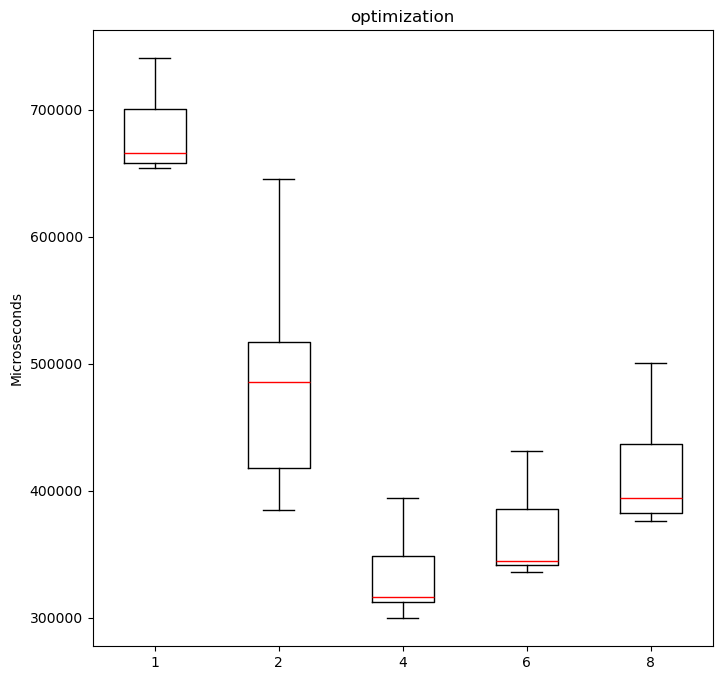

In [11]:
plot(test, "optimization", n_threads)